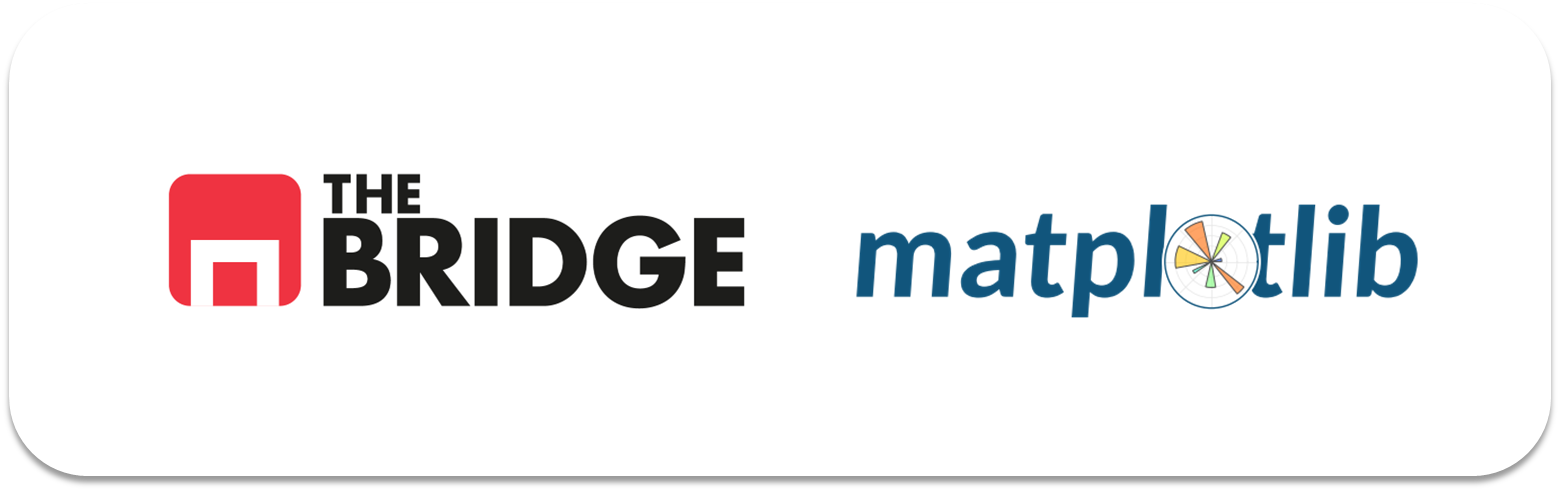

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv('./data/california_cities.csv', index_col=0)

print('Primeras filas')
display(df.head())

print('\nDescripción estadística')
display(df.describe())

print(f'\nNulos antes de limpiar: {df.isnull().sum().sum()}')
df.dropna(inplace=True)
print(f'Nulos después de limpiar: {df.isnull().sum().sum()}')
print(f'Shape final: {df.shape}')

Primeras filas


,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01



Descripción estadística


,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
count,482.000000,482.000000,434.000000,470.000000,4.820000e+02,480.000000,482.000000,481.000000,477.000000,478.000000,478.000000,477.000000
mean,36.095088,-119.837714,180.416705,567.168723,6.489493e+04,18.442183,16.840981,1.589630,46.753283,43.547021,3.125178,5.301801
std,2.298006,2.147676,309.531825,1001.265722,2.032041e+05,36.363230,32.694647,9.490386,90.972269,84.933022,11.562269,14.656428
min,32.578333,-124.263333,-34.000000,-180.000000,1.000000e+00,0.314000,0.314000,0.000000,0.813000,0.813000,0.000000,0.000000
25%,33.977292,-121.954931,22.000000,69.000000,1.090200e+04,3.708250,3.506500,0.000000,9.551000,9.025000,0.000250,0.000000
50%,36.204722,-119.708611,67.000000,200.000000,2.905750e+04,9.093000,8.362000,0.029000,23.551000,21.533000,0.078500,0.340000
75%,37.886667,-117.977292,173.500000,515.000000,6.646650e+04,19.878250,19.090000,0.244000,51.772000,49.322000,0.623250,1.870000
max,41.965000,-114.596389,2402.000000,7880.000000,3.884307e+06,503.000000,469.000000,185.020000,1302.000000,1214.000000,122.270000,84.580000



Nulos antes de limpiar: 81
Nulos después de limpiar: 0
Shape final: (427, 13)


#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

### Gráfico 1

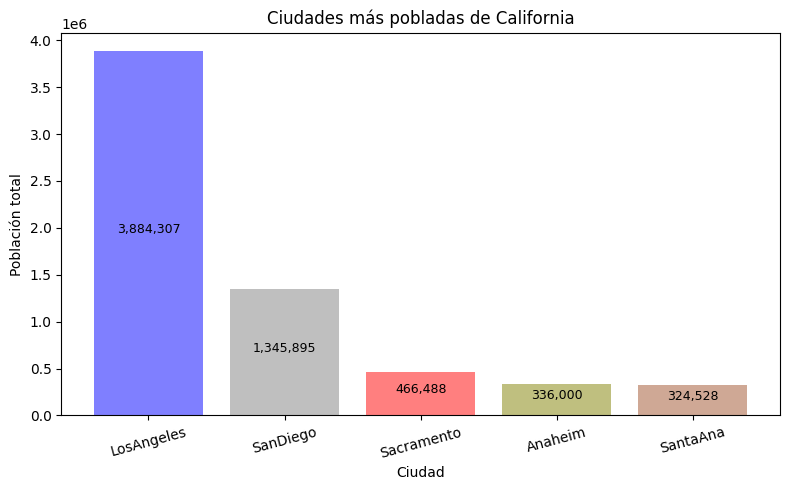

In [3]:
top5 = df.nlargest(5, 'population_total')[['city', 'population_total']].reset_index(drop=True)

#Colores: azul, gris, rojo, verde y marrón, todos al 50% de transparencia
colors_bar = [
    (0, 0, 1, 0.5),
    (0.5, 0.5, 0.5, 0.5),
    (1, 0, 0, 0.5),
    (0.502, 0.502, 0, 0.5),
    (0.627, 0.322, 0.176, 0.5)
]

fig1, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(top5['city'], top5['population_total'], color=colors_bar)
ax1.bar_label(bars,
              labels=[f'{v:,.0f}' for v in top5['population_total']],
              padding=3,
              label_type='center',
              fontsize=9)
ax1.set_title('Ciudades más pobladas de California')
ax1.set_xlabel('Ciudad')
ax1.set_ylabel('Población total')
ax1.tick_params(axis='x', rotation=15)
fig1.tight_layout()
plt.show()

### Gráfico 2

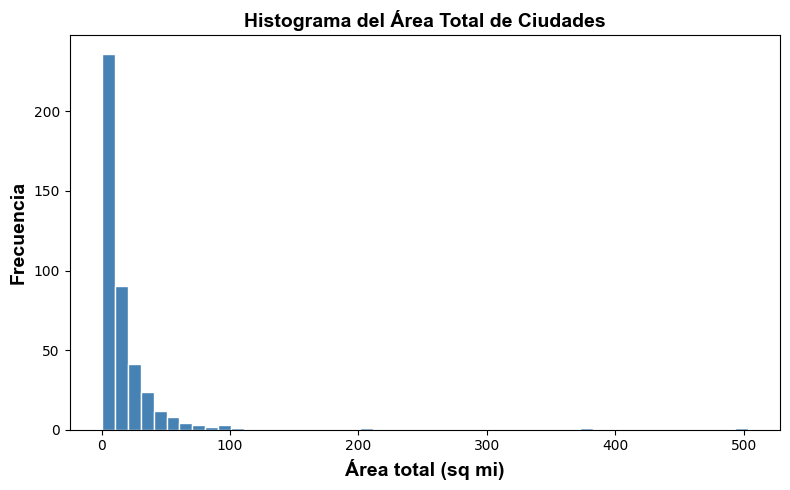

In [4]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(df['area_total_sq_mi'], bins=50, color='steelblue', edgecolor='white')
ax2.set_title('Histograma del Área Total de Ciudades',
              fontfamily='Arial', fontsize=14, fontweight='bold')
ax2.set_xlabel('Área total (sq mi)', fontfamily='Arial', fontsize=14, fontweight='bold')
ax2.set_ylabel('Frecuencia', fontfamily='Arial', fontsize=14, fontweight='bold')
fig2.tight_layout()
plt.show()

### Gráfico 3


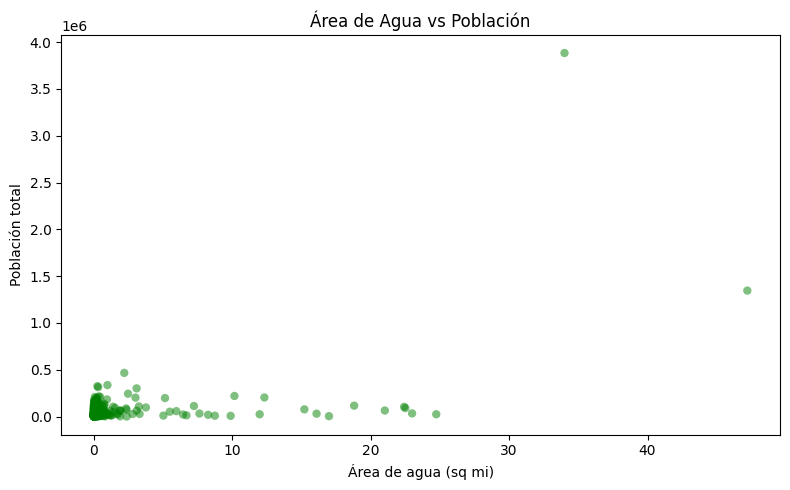

In [5]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.scatter(df['area_water_sq_mi'], df['population_total'],
            alpha=0.5, color='green', edgecolors='none')
ax3.set_title('Área de Agua vs Población')
ax3.set_xlabel('Área de agua (sq mi)')
ax3.set_ylabel('Población total')
fig3.tight_layout()
plt.show()

### Gráfico 4

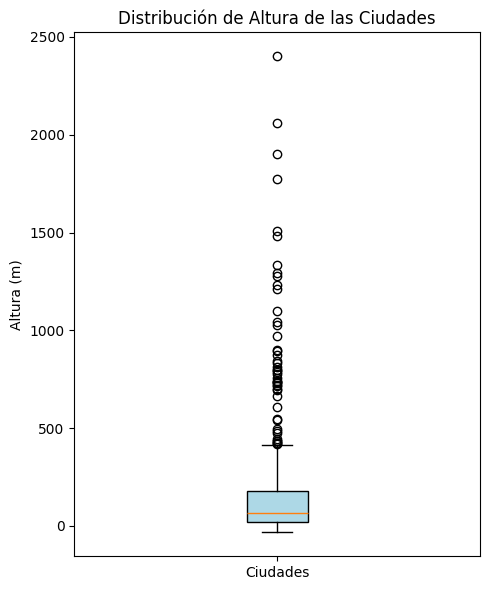

In [6]:
fig4, ax4 = plt.subplots(figsize=(5, 6))
ax4.boxplot(df['elevation_m'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax4.set_title('Distribución de Altura de las Ciudades')
ax4.set_ylabel('Altura (m)')
ax4.set_xticks([1])
ax4.set_xticklabels(['Ciudades'])
fig4.tight_layout()
plt.show()

### Figura cominada

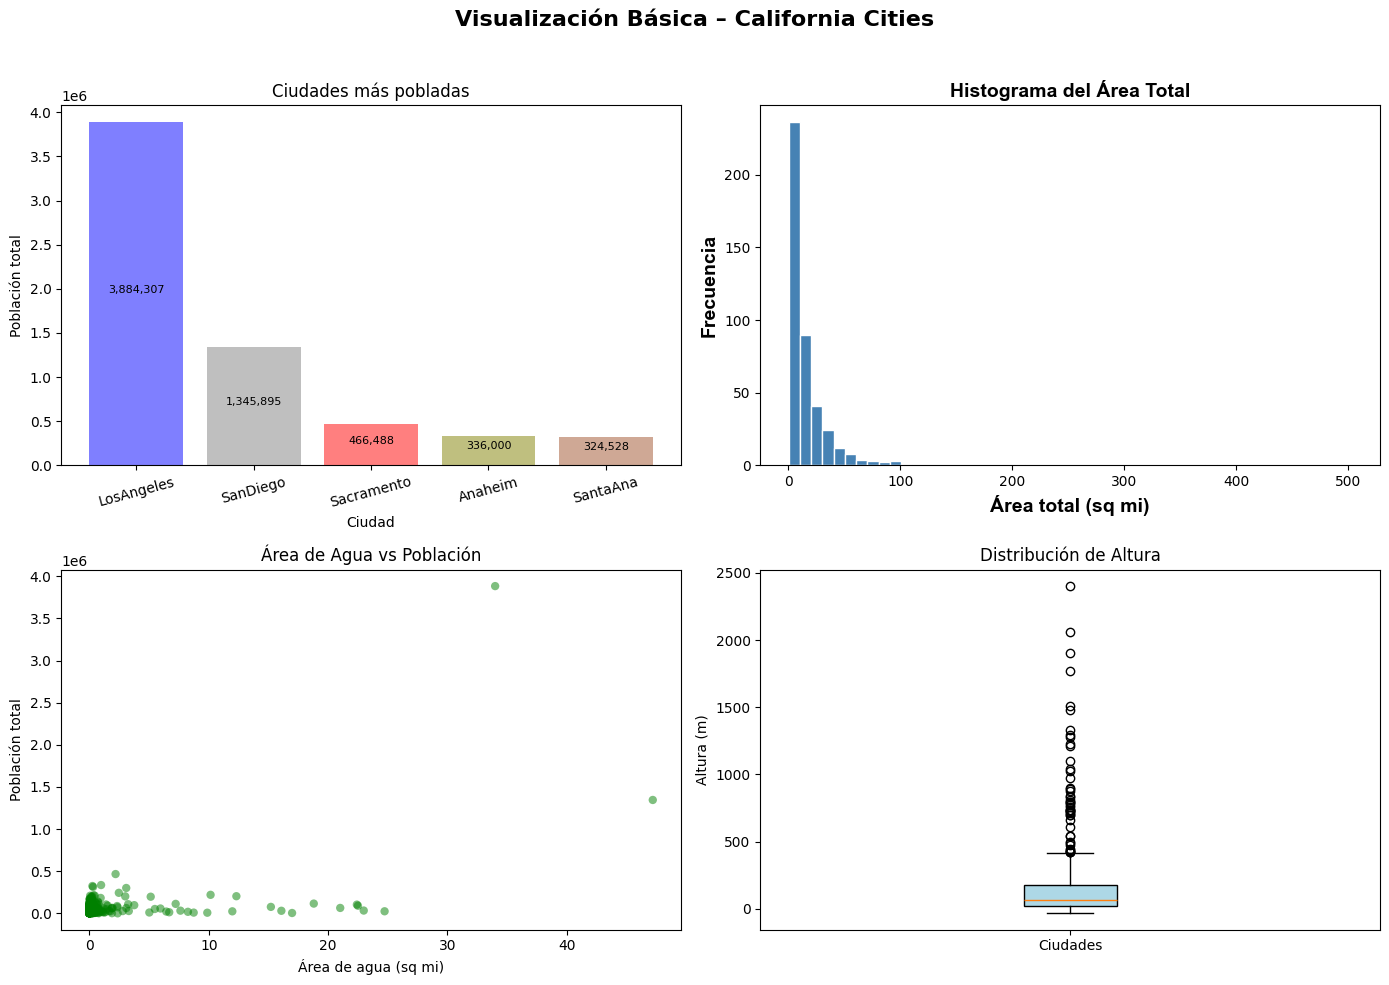

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Visualización Básica – California Cities', fontsize=16, fontweight='bold')

#Barras
ax = axes[0, 0]
bars = ax.bar(top5['city'], top5['population_total'], color=colors_bar)
ax.bar_label(bars,
             labels=[f'{v:,.0f}' for v in top5['population_total']],
             padding=3, label_type='center', fontsize=8)
ax.set_title('Ciudades más pobladas')
ax.set_xlabel('Ciudad')
ax.set_ylabel('Población total')
ax.tick_params(axis='x', rotation=15)

#Histograma
ax = axes[0, 1]
ax.hist(df['area_total_sq_mi'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Histograma del Área Total',
             fontfamily='Arial', fontsize=14, fontweight='bold')
ax.set_xlabel('Área total (sq mi)', fontfamily='Arial', fontsize=14, fontweight='bold')
ax.set_ylabel('Frecuencia', fontfamily='Arial', fontsize=14, fontweight='bold')

#Scatter
ax = axes[1, 0]
ax.scatter(df['area_water_sq_mi'], df['population_total'],
           alpha=0.5, color='green', edgecolors='none')
ax.set_title('Área de Agua vs Población')
ax.set_xlabel('Área de agua (sq mi)')
ax.set_ylabel('Población total')

#Boxplot
ax = axes[1, 1]
ax.boxplot(df['elevation_m'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('Distribución de Altura')
ax.set_ylabel('Altura (m)')
ax.set_xticks([1])
ax.set_xticklabels(['Ciudades'])

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

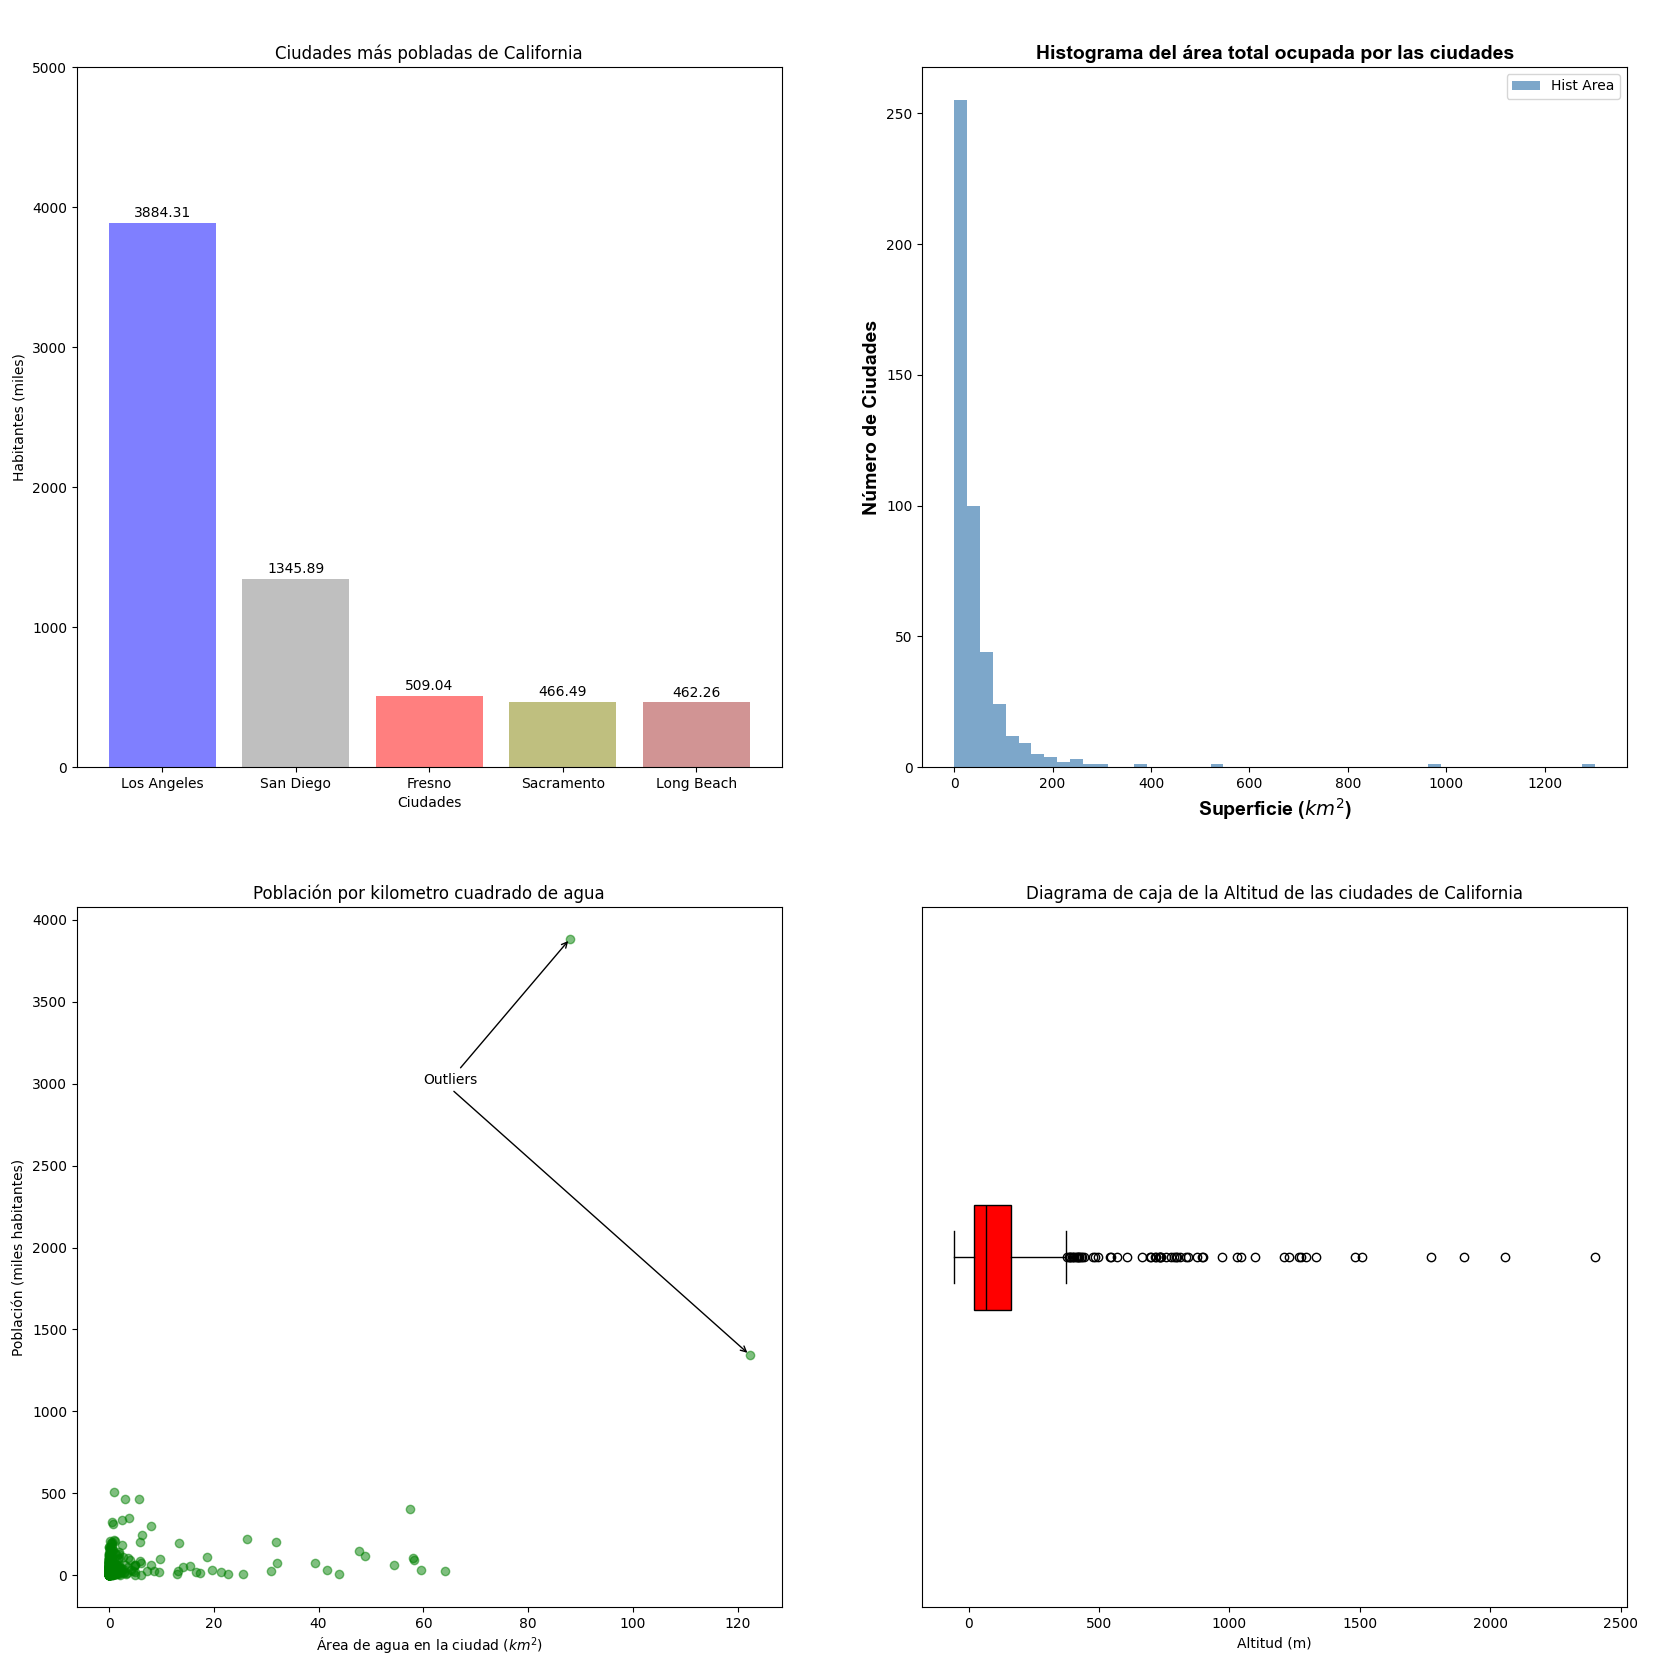

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [8]:
fig.savefig('practica_obligatoria.png', dpi=150, bbox_inches='tight')
print('Figura guardada como practica_obligatoria.png')

Figura guardada como practica_obligatoria.png
